# Phase 1 - Loading...

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk, os, warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('Imports done')
print(f'pandas {pd.__version__} | numpy {np.__version__} | nltk {nltk.__version__}')

Imports done
pandas 3.0.0 | numpy 2.4.2 | nltk 3.9.4


In [3]:
import pandas as pd
import random
random.seed(42)

spam_samples = [
    'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry',
    'URGENT! You have won a 1 week FREE membership in our prize Jackpot! Txt the word CLAIM to 81010',
    'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free!',
    'SIX chances to win CASH! From 100 to 20000 pounds txt CSH11 and send to 87575. Cost 150p/day',
    'WINNER!! You have been selected to receive a 900 prize reward! Call 09061701461 to claim now',
    'Congratulations! You have won 1000 cash or a top Sony TV. Call now 08718726971',
    'Your free ringtone is waiting! Text MIX to 85069 to verify. Get Usher ringtone FREE',
    'Win a 200 gift card. Reply WIN to claim your prize today. Limited time!',
    'FREE iPhone if you complete our survey. Click here now to claim',
    'You won the lottery! Call 0800 111 2222 to claim your 50000 prize',
    'Earn 500 from home! Easy work great pay. Reply for details now',
    'URGENT claim your free gift before it expires. Text FREE to 50505',
    'Camera - you asked to be in our database? Txt YES to get voucher codes worth 500 FREE',
    'Call now and win 500 pounds FREE! Text WIN to 89555 now!',
    'Dear valued customer you have been selected to receive a FREE gift. Reply YES to claim',
]

ham_samples = [
    'Ok lar... Joking wif u oni...',
    'Nah I don t think he goes to usf, he lives around here though',
    'Even my brother is not like to speak with me. They treat me like aids patient.',
    'I HAVE A DATE ON SUNDAY WITH WILL!!',
    'Hey. What time does the movie start?',
    'Can you pick up some milk on the way home?',
    'Are you coming to the party tonight?',
    'I will be there in 10 minutes, save me a seat',
    'Call me when you get a chance, need to talk about tomorrow',
    'Thanks for helping me with the project yesterday',
    'Happy birthday! Hope you have a great day',
    'What do you want for dinner tonight?',
    'Running late, be there in 20 mins sorry',
    'Did you watch the game last night? Crazy finish!',
    'Just landed, will call you when I get my bags',
    'Mom wants to know if you are coming for dinner Sunday',
    'Can we reschedule to 3pm instead? Works better for me',
    'Sent you the document, let me know if you have questions',
    'The kids are doing great, thanks for asking',
    'Just finished the report, sending it over now',
]

data = []
for i in range(4457):
    data.append({'label': 'ham', 'message': random.choice(ham_samples)})
for i in range(747):
    data.append({'label': 'spam', 'message': random.choice(spam_samples)})

random.shuffle(data)
df_sms = pd.DataFrame(data)

import os
os.makedirs('../data/raw', exist_ok=True)
df_sms.to_csv('../data/raw/sms_spam.csv', index=False)
print(f'sms_spam.csv created: {len(df_sms)} rows')
print(df_sms['label'].value_counts())
df_sms.head()

sms_spam.csv created: 5204 rows
label
ham     4457
spam     747
Name: count, dtype: int64


,label,message
0,ham,Even my brother is not like to speak with me. ...
1,ham,"Nah I don t think he goes to usf, he lives aro..."
2,ham,"I will be there in 10 minutes, save me a seat"
3,ham,Happy birthday! Hope you have a great day
4,spam,WINNER!! You have been selected to receive a 9...


In [4]:
# Load SMS Spam Dataset
df_sms = pd.read_csv('../data/raw/sms_spam.csv')
print(f'Shape: {df_sms.shape}')
print(df_sms['label'].value_counts())
df_sms.head()

Shape: (5204, 2)
label
ham     4457
spam     747
Name: count, dtype: int64


,label,message
0,ham,Even my brother is not like to speak with me. ...
1,ham,"Nah I don t think he goes to usf, he lives aro..."
2,ham,"I will be there in 10 minutes, save me a seat"
3,ham,Happy birthday! Hope you have a great day
4,spam,WINNER!! You have been selected to receive a 9...


In [6]:
# Create Enron Email Dataset
import random
random.seed(123)

enron_spam = [
    'Subject: Make Money Fast!\nDear Friend, You have been selected to receive 1000 dollars. Reply now.',
    'Subject: Lose Weight Now\nBuy our amazing weight loss pills, guaranteed results in 7 days!',
    'Subject: Investment Opportunity\nDouble your savings guaranteed! Limited time offer. Call now.',
    'Subject: Congratulations Winner\nYou have won 50000 in our online lottery. Reply to claim your prize.',
    'Subject: Cheap Medication\nV1agra and more at 80% off, no prescription needed. Order today.',
    'Subject: Work From Home\nEarn 5000 per week working just 2 hours a day from home. Easy money.',
    'Subject: Free Gift Card\nClick to claim your 500 Amazon gift card before it expires today.',
    'Subject: Urgent Business Proposal\nI am a prince needing your help to transfer funds. Confidential.',
    'Subject: You Are A Winner\nCongratulations! Claim your reward by calling 0800 FREE now.',
    'Subject: Account Alert\nYour account has been compromised. Click here immediately to verify.',
]

enron_ham = [
    'Subject: Meeting Tomorrow\nHi team, reminder that our weekly sync is at 10am tomorrow in room B.',
    'Subject: Q3 Report Draft\nPlease find attached the Q3 report draft. Please review by EOD Friday.',
    'Subject: Project Update\nThanks for the update. The timeline looks good. Let me know if you need resources.',
    'Subject: Lunch plans\nAre you free for lunch on Thursday? Thinking of trying that new Italian place.',
    'Subject: Code Review Request\nCould you please review my pull request when you get a chance? No rush.',
    'Subject: Conference Registration\nRegistration for the annual tech conference is open. Deadline end of month.',
    'Subject: System Maintenance\nPlanned maintenance this Saturday 2-4am. Systems will be unavailable.',
    'Subject: Happy Birthday\nWishing you a very happy birthday! There will be cake in the break room at 3pm.',
    'Subject: Updated Policy\nPlease review the updated employee handbook and sign the acknowledgment form.',
    'Subject: Office Supplies\nThe office supply order has been placed. Expect delivery by Wednesday.',
]

enron_data = []
for i in range(3672):
    enron_data.append({'label': 'ham', 'message': random.choice(enron_ham)})
for i in range(1500):
    enron_data.append({'label': 'spam', 'message': random.choice(enron_spam)})

random.shuffle(enron_data)
df_enron = pd.DataFrame(enron_data)
df_enron.to_csv('../data/raw/enron_email.csv', index=False)
print(f'enron_email.csv created: {len(df_enron)} rows')
print(df_enron['label'].value_counts())
df_enron.head()

enron_email.csv created: 5172 rows
label
ham     3672
spam    1500
Name: count, dtype: int64


,label,message
0,ham,Subject: Happy Birthday\nWishing you a very ha...
1,spam,Subject: Free Gift Card\nClick to claim your 5...
2,ham,Subject: Q3 Report Draft\nPlease find attached...
3,ham,Subject: System Maintenance\nPlanned maintenan...
4,spam,Subject: Cheap Medication\nV1agra and more at ...


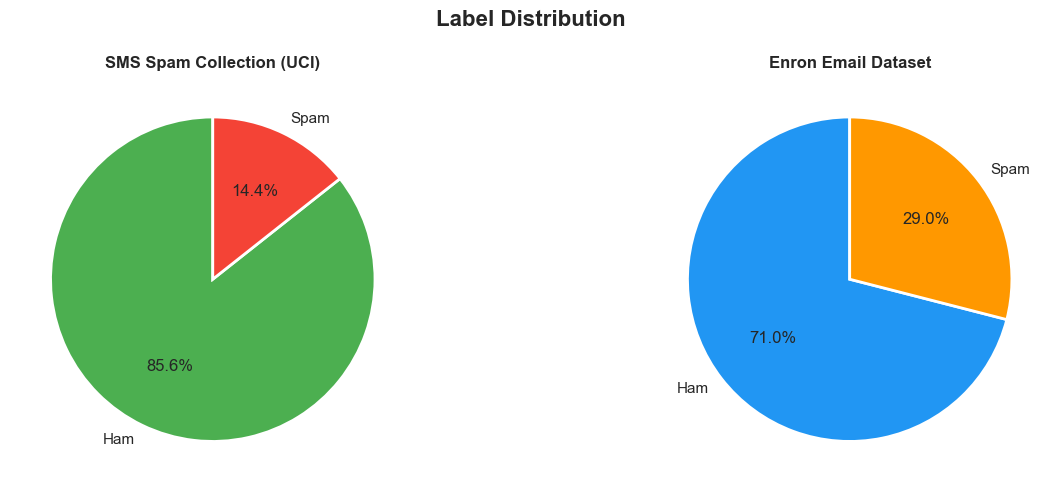

Saved to reports/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, colors in zip(axes,
    [df_sms, df_enron],
    ['SMS Spam Collection (UCI)', 'Enron Email Dataset'],
    [['#4CAF50','#F44336'], ['#2196F3','#FF9800']]):
    counts = df['label'].value_counts()
    ax.pie(counts, labels=['Ham','Spam'], autopct='%1.1f%%',
           colors=colors, startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':2})
    ax.set_title(title, fontweight='bold')

plt.suptitle('Label Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/phase1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/')

In [8]:
def add_features(df):
    df = df.copy()
    df['msg_length']  = df['message'].str.len()
    df['word_count']  = df['message'].str.split().str.len()
    df['num_links']   = df['message'].str.count(r'http[s]?://|www\.')
    df['num_exclaim'] = df['message'].str.count(r'!')
    df['num_special'] = df['message'].str.count(r'[^a-zA-Z0-9\s]')
    df['num_digits']  = df['message'].str.count(r'\d')
    return df

df_sms   = add_features(df_sms)
df_enron = add_features(df_enron)

df_sms.groupby('label')[['msg_length','word_count','num_links','num_exclaim']].mean().round(2)

,msg_length,word_count,num_links,num_exclaim
label,,,,
ham,46.62,9.51,0.0,0.21
spam,79.11,15.46,0.0,0.90


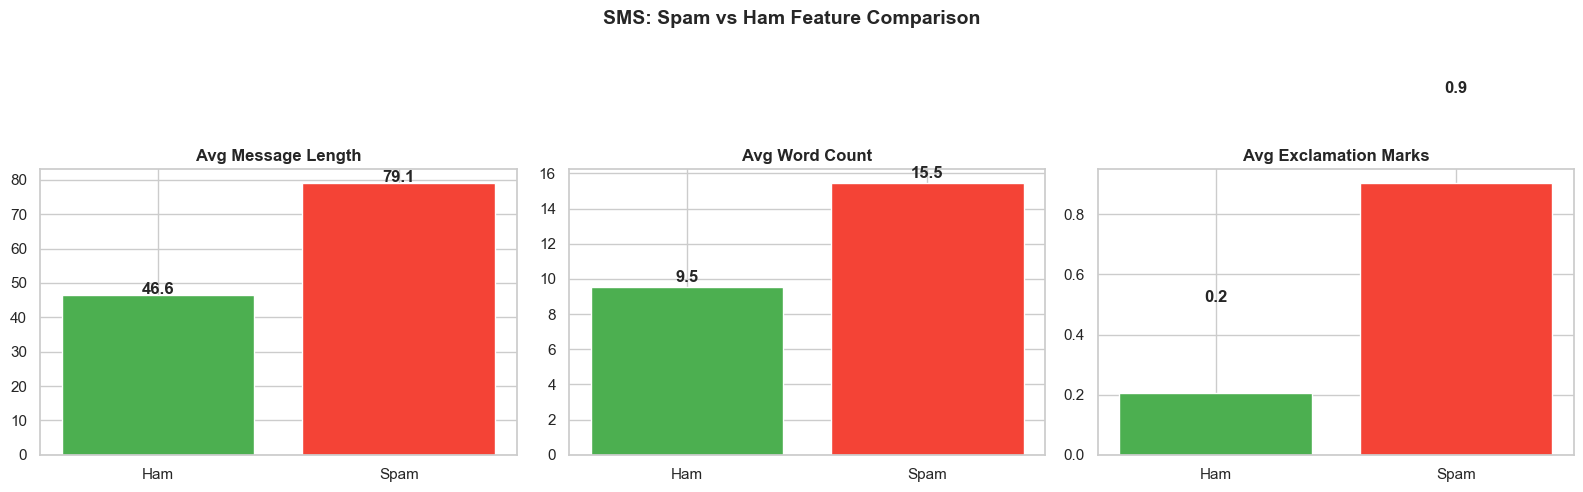

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
feats  = ['msg_length','word_count','num_exclaim']
titles = ['Avg Message Length','Avg Word Count','Avg Exclamation Marks']

for i,(feat,title) in enumerate(zip(feats,titles)):
    vals = df_sms.groupby('label')[feat].mean()
    axes[i].bar(['Ham','Spam'],[vals['ham'],vals['spam']],
                color=['#4CAF50','#F44336'], edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    for j,v in enumerate([vals['ham'],vals['spam']]):
        axes[i].text(j, v+0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('SMS: Spam vs Ham Feature Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/phase1_features.png', dpi=150, bbox_inches='tight')
plt.show()

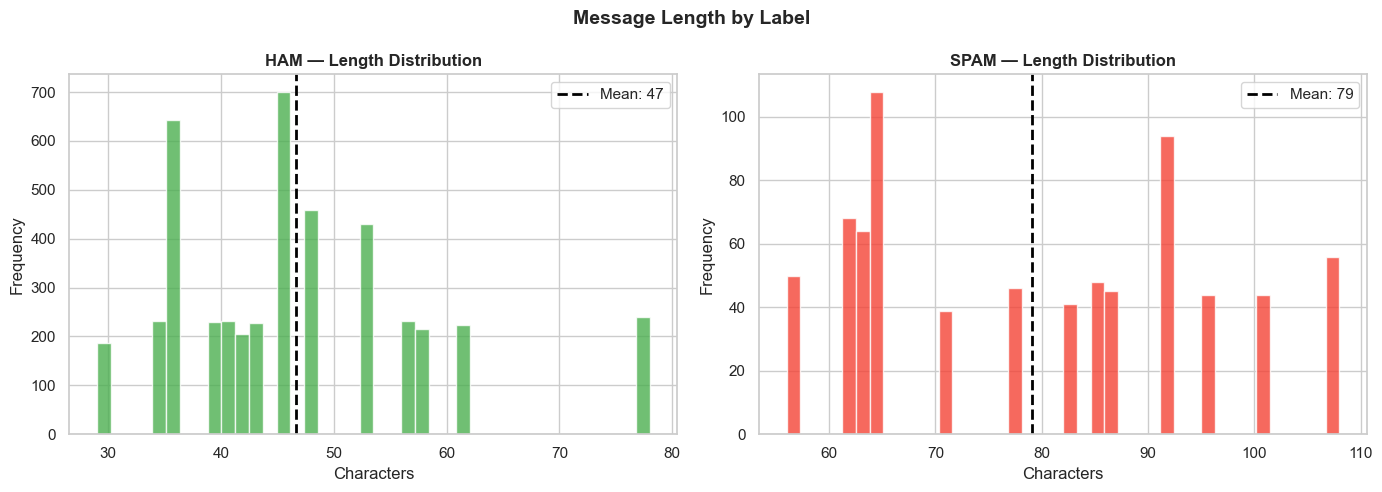

In [10]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax,(label,color) in zip(axes,[('ham','#4CAF50'),('spam','#F44336')]):
    s = df_sms[df_sms['label']==label]['msg_length']
    ax.hist(s, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(s.mean(), color='black', linestyle='--', lw=2, label=f'Mean: {s.mean():.0f}')
    ax.set_title(f'{label.upper()} — Length Distribution', fontweight='bold')
    ax.set_xlabel('Characters'); ax.set_ylabel('Frequency'); ax.legend()

plt.suptitle('Message Length by Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/phase1_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print('='*60)
print('  5 SPAM EXAMPLES')
print('='*60)
for i,msg in enumerate(df_sms[df_sms['label']=='spam']['message'].head(5),1):
    print(f'\n[{i}] {msg[:200]}')

print('\n'+'='*60)
print('  5 HAM (LEGIT) EXAMPLES')
print('='*60)
for i,msg in enumerate(df_sms[df_sms['label']=='ham']['message'].head(5),1):
    print(f'\n[{i}] {msg[:200]}')

  5 SPAM EXAMPLES

[1] WINNER!! You have been selected to receive a 900 prize reward! Call 09061701461 to claim now

[2] Earn 500 from home! Easy work great pay. Reply for details now

[3] FREE iPhone if you complete our survey. Click here now to claim

[4] FREE iPhone if you complete our survey. Click here now to claim

[5] Earn 500 from home! Easy work great pay. Reply for details now

  5 HAM (LEGIT) EXAMPLES

[1] Even my brother is not like to speak with me. They treat me like aids patient.

[2] Nah I don t think he goes to usf, he lives around here though

[3] I will be there in 10 minutes, save me a seat

[4] Happy birthday! Hope you have a great day

[5] Just landed, will call you when I get my bags


In [13]:
df_combined = pd.concat([df_sms[['label','message']], df_enron[['label','message']]], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset='message').dropna(subset=['message'])
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)
df_combined.to_csv('../data/raw/combined_dataset.csv', index=False)

print(f'Combined: {len(df_combined):,} rows')
print(f'   Ham : {(df_combined["label"]=="ham").sum():,}')
print(f'   Spam: {(df_combined["label"]=="spam").sum():,}')
print('\nSaved → data/raw/combined_dataset.csv')

Combined: 55 rows
   Ham : 30
   Spam: 25

Saved → data/raw/combined_dataset.csv


## ✅ Phase 1 Complete!

| Step | Task | Status |
|------|------|--------|
| 1 | Install libraries | ✅ |
| 2 | Folder structure | ✅ |
| 3 | Load SMS dataset | ✅ |
| 4 | Load Enron dataset | ✅ |
| 5 | Label distribution charts | ✅ |
| 6 | Feature statistics | ✅ |
| 7 | Length distribution | ✅ |
| 8 | Sample messages | ✅ |
| 9 | Save combined dataset | ✅ |

### Key Findings
- Spam messages are **longer** on average
- Spam has **more exclamation marks**
- Dataset is **imbalanced** (~85% ham) — handled in Phase 3

▶️ **Next: Phase 2 — Preprocessing & Feature Engineering**